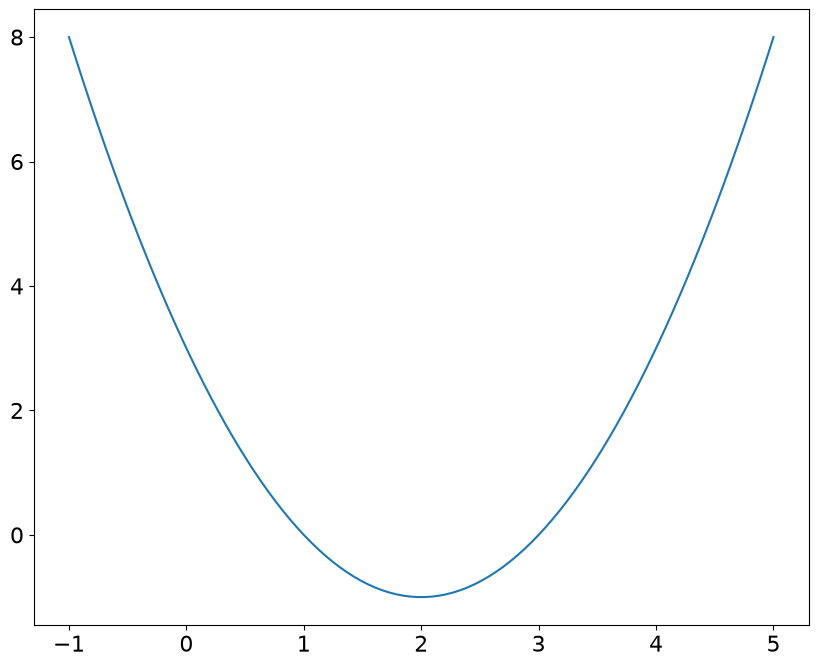

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_x = np.linspace(-1, 5, 100)
plot_y = plot_x ** 2 - 4 * plot_x + 3

plt.plot(plot_x, plot_y)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [ ]:
def fit_gd(X_train, y_train, eta=0.01, n_iters=1e10):
    assert X_train.shape[0] == y_train.shape[0], 'the size of X_train must be equal to the size of y_train'
    
    def J(theta, X_b, y):
        try:
            return np.sum((y - X_b.dot(theta)) ** 2) / len(y)
        except:
            return float('inf')
        
    def dJ(theta, X_b, y):
        return X_b.T.dot(X_b.dot(theta) - y) * 2. / len(y)
    
    def gradient_descent(X_b, y, initial_theta, eta, n_iters=1e10, epsilon=1e-8):
        theta = initial_theta
        cur_iter = 0
        while cur_iter < n_iters:
            gradient = dJ(theta, X_b, y)
            last_theta = theta
            theta = theta - eta * gradient
            if abs(J(theta, X_b, y) - J(last_theta, X_b, y)) < epsilon:
                break
            cur_iter += 1
        return theta
    
    X_b = np.hstack([np.ones((len(X_train), 1)), X_train])
    initial_theta = np.zeros(X_b.shape[1])
    theta = gradient_descent(X_b, y_train, initial_theta, eta, n_iters)
    return theta

In [ ]:
theta = fit_gd(X, y, eta=0.007)
print(theta)

In [ ]:
def fit_sgd(X_train, y_train, eta=0.01, n_iters=10000):
    assert X_train.shape[0] == y_train.shape[0], 'the size of X_train must be equal to the size of y_train'

    def dJ_sgd(theta, x_b, y):
        return 2 * x_b.T.dot(x_b.dot(theta) - y)

    def sgd(X_b, y, initial_theta, eta, n_iters=50):
        theta = initial_theta
        m = len(X_b)
        for _ in range(n_iters):
            indices = np.random.permutation(m)
            X_b_shuffled = X_b[indices]
            y_shuffled = y[indices]
            for i in range(m):
                xi = X_b_shuffled[i:i+1]  # shape (1, n)
                yi = y_shuffled[i]
                gradient = dJ_sgd(theta, xi, yi)
                theta = theta - eta * gradient
        return theta

    X_b = np.hstack([np.ones((len(X_train), 1)), X_train])
    initial_theta = np.zeros(X_b.shape[1])
    theta = sgd(X_b, y_train, initial_theta, eta, n_iters)
    return theta

In [ ]:
theta = fit_sgd(X, y, eta=0.007)
print(theta)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
print(f'mean: {scaler.mean_}')
print(f'scale: {scaler.scale_}')

In [ ]:
x_scaled = scaler.transform(X)
print(x_scaled)

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(x_scaled.reshape(1, -1), y, s=120)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-6, penalty=None, eta0=0.01, learning_rate='constant', random_state=42)
sgd_reg.fit(x_scaled, y)

print(sgd_reg.intercept_, sgd_reg.coef_)

coef_sgd = sgd_reg.coef_[0] / scaler.scale_[0]
intercept_sgd = y.mean() - coef_sgd * x.mean()

print("---------------------------")
print(f"coef_: {coef_sgd:.5f}")
print(f"intercept_: {intercept_sgd:.5f}")

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

diabetes = datasets.load_diabetes()
x_train, x_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(x_train[0:1])

In [ ]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-6, penalty=None, eta0=0.01, learning_rate='constant', random_state=42)
sgd_reg.fit(x_train, y_train)
print(sgd_reg.score(x_test, y_test))

In [ ]:
np.random.seed(666)
X = np.random.random(size=(1000, 10))
true_theta = np.arange(1, 12, dtype=float)
X_b = np.hstack([np.ones((len(X), 1)), X])
y = X_b.dot(true_theta)
print(X.shape)
print(y.shape)
print(true_theta)

In [ ]:
def J(theta, X_b, y):
    try:
        return np.sum((y - X_b.dot(theta)) ** 2) / len(y)
    except:
        return float('inf')

In [ ]:
def dJ_math(theta, X_b, y):
    return X_b.T.dot(X_b.dot(theta) - y) * 2. / len(y)

In [ ]:
def dJ_debug(theta, X_b, y, epsilon=0.01):
    res = np.empty(len(theta))
    for i in range(len(theta)):
        theta_1 = theta.copy()
        theta_1[i] += epsilon
        theta_2 = theta.copy()
        theta_2[i] -= epsilon
        res[i] = (J(theta_1, X_b, y) - J(theta_2, X_b, y)) / (2 * epsilon)
    return res

In [ ]:
def gradient_descent(dJ, X_b, y, initial_theta, eta, n_iters=1e4, epsilon=1e-8):
    theta = initial_theta
    cur_iter = 0
    while cur_iter < n_iters:
        gradient = dJ(theta, X_b, y)
        last_theta = theta
        theta = theta - eta * gradient
        if abs(J(theta, X_b, y) - J(last_theta, X_b, y)) < epsilon:
            break
        cur_iter += 1
    return theta

In [ ]:
X_b = np.hstack([np.ones((len(X), 1)), X])
initial_theta = np.zeros(X_b.shape[1])
eta = 0.01

In [ ]:
theta_debug = gradient_descent(dJ_debug, X_b, y, initial_theta, eta)
print(theta_debug)

In [ ]:
theta_math = gradient_descent(dJ_math, X_b, y, initial_theta, eta)
print(theta_math)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 构造数据集并进行标准化 (Feature Scaling)
np.random.seed(42)
m = 40
x_raw = np.random.uniform(1, 8, m)
x = (x_raw - np.mean(x_raw)) / np.std(x_raw)  # 均值为0，方差为1

true_a, true_b = 2.5, 5.0
y = true_a * x + true_b + np.random.normal(0, 1.2, m)

# 2. 计算极小值点 (a*, b*)
a_opt, b_opt = np.polyfit(x, y, 1)
L_min = np.sum((y - (a_opt * x + b_opt))**2)

# 3. 以极小值点为中心构建对称网格
delta = 3.0
a_vals = np.linspace(a_opt - delta, a_opt + delta, 100)
b_vals = np.linspace(b_opt - delta, b_opt + delta, 100)
A, B = np.meshgrid(a_vals, b_vals)

# 4. 计算损失值 L(a, b)
L = np.zeros_like(A)
for i in range(m):
    L += (y[i] - (A * x[i] + B))**2

# 5. 绘图
fig = plt.figure(figsize=(14, 6), dpi=150)

# 3D 碗形曲面
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(A, B, L, cmap='viridis', alpha=0.9, antialiased=True)
ax1.scatter([a_opt], [b_opt], [L_min], color='red', s=100, label=f'Minimizer ({a_opt:.2f}, {b_opt:.2f})')
ax1.set_xlabel('Parameter a', fontsize=18)
ax1.set_ylabel('Parameter b', fontsize=18)
ax1.set_zlabel('Loss L(a, b)', fontsize=18)
ax1.set_title('3D Surface', fontsize=18)
ax1.view_init(elev=25, azim=125)

# 2D 同心圆等高线
ax2 = fig.add_subplot(122)
CS = ax2.contour(A, B, L, levels=15, cmap='viridis')
ax2.clabel(CS, inline=True, fontsize=8)
ax2.plot(a_opt, b_opt, 'r*', markersize=14)
ax2.set_aspect('equal', 'box') # 保持等比例以呈现正圆
ax2.set_xlabel('Parameter a', fontsize=18)  
ax2.set_ylabel('Parameter b', fontsize=18)
ax2.set_title('2D Concentric Circles', fontsize=18)
ax2.set_ylabel('Parameter b')

plt.tight_layout()
plt.show()